In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

train_path = "/content/drive/MyDrive/BrainTumorDataset/Training"
test_path = "/content/drive/MyDrive/BrainTumorDataset/Testing"

print("Training Exists:", os.path.exists(train_path))
print("Testing Exists:", os.path.exists(test_path))

Training Exists: True
Testing Exists: True


In [3]:
TRAIN_DIR = "/content/drive/MyDrive/BrainTumorDataset/Training"

TEST_DIR = "/content/drive/MyDrive/BrainTumorDataset/Testing"

In [4]:
# ==================================================
# MEDVISION AI
# Brain MRI Tumor Detection
# PART 1 - Imports
# ==================================================

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

print("PyTorch Version :", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

PyTorch Version : 2.11.0+cu128
Device : cuda


In [5]:
# ==================================================
# Dataset Paths
# ==================================================

TRAIN_DIR = "/content/drive/MyDrive/BrainTumorDataset/Training"
TEST_DIR  = "/content/drive/MyDrive/BrainTumorDataset/Testing"

print(TRAIN_DIR)
print(TEST_DIR)

/content/drive/MyDrive/BrainTumorDataset/Training
/content/drive/MyDrive/BrainTumorDataset/Testing


In [6]:
# ==================================================
# Dataset Paths
# ==================================================

TRAIN_DIR = "/content/drive/MyDrive/BrainTumorDataset/Training"
TEST_DIR  = "/content/drive/MyDrive/BrainTumorDataset/Testing"

print(TRAIN_DIR)
print(TEST_DIR)

/content/drive/MyDrive/BrainTumorDataset/Training
/content/drive/MyDrive/BrainTumorDataset/Testing


In [7]:
# ==================================================
# Image Configuration
# ==================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32

print("Image Size :", IMAGE_SIZE)
print("Batch Size :", BATCH_SIZE)

Image Size : 224
Batch Size : 32


In [8]:
# ==================================================
# Training Transformations
# ==================================================

train_transforms = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ==================================================
# Testing Transformations
# ==================================================

test_transforms = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

print("Transforms Created Successfully")

Transforms Created Successfully


In [9]:
# ==================================================
# Load Datasets
# ==================================================

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transforms
)

print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

Training Images : 5600
Testing Images  : 1600


In [10]:
# ==================================================
# Class Names
# ==================================================

class_names = train_dataset.classes

print("Classes Found:\n")

for idx, name in enumerate(class_names):

    print(f"{idx} --> {name}")

Classes Found:

0 --> glioma
1 --> meningioma
2 --> notumor
3 --> pituitary


In [11]:
# ==================================================
# DataLoaders
# ==================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoaders Created Successfully")

DataLoaders Created Successfully


In [12]:
# ==================================================
# Verify Shapes
# ==================================================

images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])


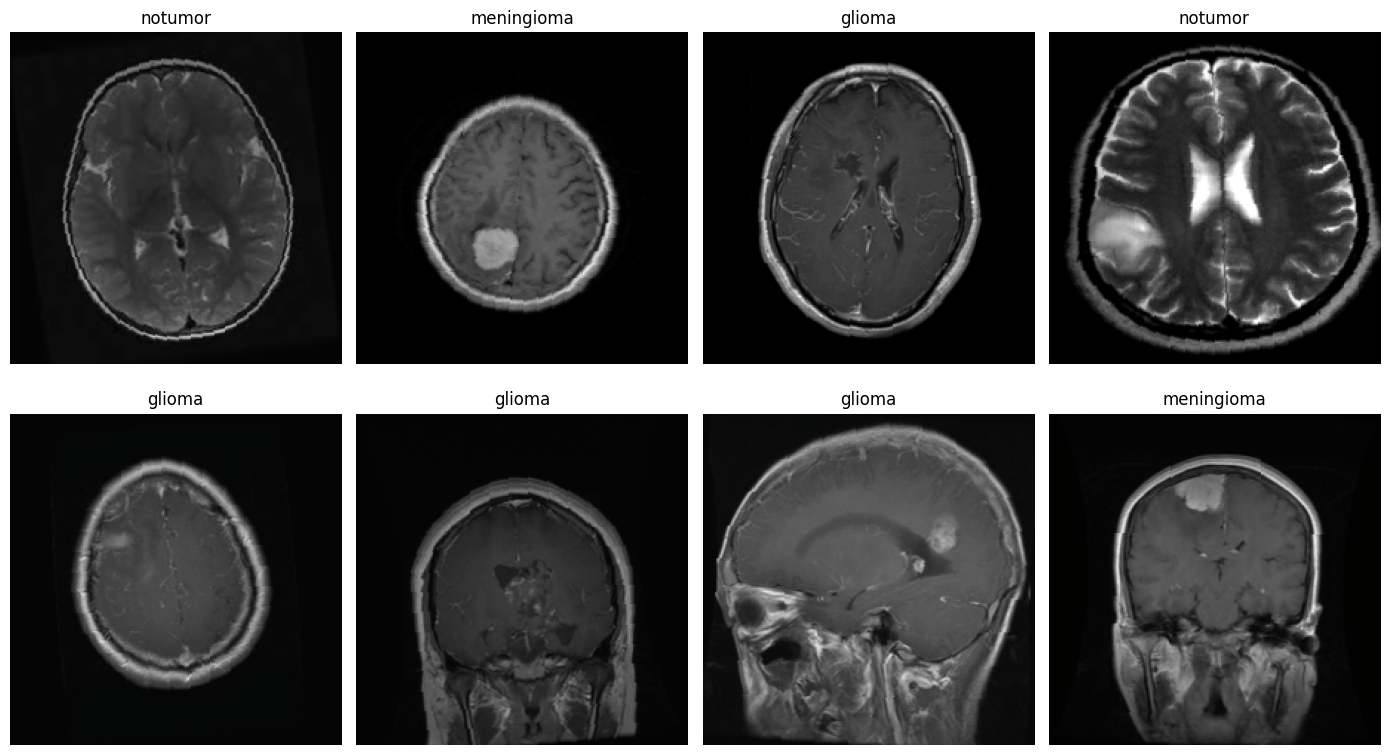

In [13]:
# ==================================================
# Visualize MRI Images
# ==================================================

def show_batch():

    images, labels = next(iter(train_loader))

    plt.figure(figsize=(14,8))

    for i in range(8):

        plt.subplot(2,4,i+1)

        img = images[i].numpy().transpose(1,2,0)

        mean = np.array([0.485,0.456,0.406])
        std = np.array([0.229,0.224,0.225])

        img = std * img + mean
        img = np.clip(img,0,1)

        plt.imshow(img)

        plt.title(class_names[labels[i]])

        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch()

In [14]:
!pip install torchinfo -q

In [15]:
from torchvision import models
from torchinfo import summary

import torch.nn as nn
import torch.optim as optim

In [16]:
# ==================================================
# Load EfficientNet-B0
# ==================================================

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

print("Pretrained EfficientNet Loaded")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 67.3MB/s]


Pretrained EfficientNet Loaded


In [17]:
# ==================================================
# Replace Classifier Head
# ==================================================

num_features = model.classifier[1].in_features

print("Input Features:", num_features)

model.classifier = nn.Sequential(

    nn.Dropout(0.3),

    nn.Linear(
        num_features,
        4
    )
)

print(model.classifier)

Input Features: 1280
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


In [18]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cuda


In [19]:
# ==================================================
# Loss Function
# ==================================================

criterion = nn.CrossEntropyLoss()

print("Loss Function Created")

Loss Function Created


In [20]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

print("Optimizer Created")

Optimizer Created


In [21]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

print("Scheduler Created")

Scheduler Created


In [22]:
# ==================================================
# Test Forward Pass
# ==================================================

sample_batch, _ = next(iter(train_loader))

sample_batch = sample_batch.to(device)

with torch.no_grad():

    outputs = model(sample_batch)

print("Output Shape:", outputs.shape)

Output Shape: torch.Size([32, 4])


In [23]:
summary(
    model,
    input_size=(1,3,224,224)
)

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 4]                    --
├─Sequential: 1-1                                       [1, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [1, 32, 112, 112]         864
│    │    └─BatchNorm2d: 3-2                            [1, 32, 112, 112]         64
│    │    └─SiLU: 3-3                                   [1, 32, 112, 112]         --
│    └─Sequential: 2-2                                  [1, 16, 112, 112]         --
│    │    └─MBConv: 3-4                                 [1, 16, 112, 112]         1,448
│    └─Sequential: 2-3                                  [1, 24, 56, 56]           --
│    │    └─MBConv: 3-5                                 [1, 24, 56, 56]           6,004
│    │    └─MBConv: 3-6                              

In [24]:
# ==================================================
# Training Configuration
# ==================================================

EPOCHS = 15

best_accuracy = 0.0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

print("Training Configuration Ready")

Training Configuration Ready


In [25]:
# ==================================================
# Training Function
# ==================================================

def train_one_epoch(model,
                    loader,
                    criterion,
                    optimizer,
                    device):

    model.train()

    running_loss = 0.0

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [26]:
# ==================================================
# Validation Function
# ==================================================

def validate(model,
             loader,
             criterion,
             device):

    model.eval()

    running_loss = 0.0

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [27]:
# ==================================================
# Main Training Loop
# ==================================================

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        test_loader,
        criterion,
        device
    )

    scheduler.step(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "best_brain_model.pth"
        )

        print(
            f"Best Model Saved "
            f"(Accuracy = {best_accuracy:.2f}%)"
        )

Epoch [1/15] | Train Loss: 0.4565 | Train Acc: 86.16% | Val Loss: 0.3078 | Val Acc: 89.75%
Best Model Saved (Accuracy = 89.75%)
Epoch [2/15] | Train Loss: 0.1532 | Train Acc: 94.68% | Val Loss: 0.2408 | Val Acc: 93.62%
Best Model Saved (Accuracy = 93.62%)
Epoch [3/15] | Train Loss: 0.0835 | Train Acc: 97.18% | Val Loss: 0.2474 | Val Acc: 94.19%
Best Model Saved (Accuracy = 94.19%)
Epoch [4/15] | Train Loss: 0.0530 | Train Acc: 98.18% | Val Loss: 0.2338 | Val Acc: 95.31%
Best Model Saved (Accuracy = 95.31%)
Epoch [5/15] | Train Loss: 0.0394 | Train Acc: 98.64% | Val Loss: 0.2362 | Val Acc: 95.31%
Epoch [6/15] | Train Loss: 0.0337 | Train Acc: 98.95% | Val Loss: 0.2850 | Val Acc: 94.81%
Epoch [7/15] | Train Loss: 0.0292 | Train Acc: 99.09% | Val Loss: 0.2554 | Val Acc: 95.31%
Epoch [8/15] | Train Loss: 0.0240 | Train Acc: 99.20% | Val Loss: 0.2762 | Val Acc: 95.00%
Epoch [9/15] | Train Loss: 0.0186 | Train Acc: 99.38% | Val Loss: 0.2634 | Val Acc: 95.62%
Best Model Saved (Accuracy = 95.6

In [28]:
import os

print(
    "Model Saved:",
    os.path.exists("best_brain_model.pth")
)

Model Saved: True


In [29]:
!pip install seaborn scikit-learn -q

In [30]:
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import pandas as pd

In [31]:
# ==========================================
# Load Best Model
# ==========================================

best_model = models.efficientnet_b0(
    weights=None
)

best_model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(1280,4)
)

best_model.load_state_dict(
    torch.load(
        "best_brain_model.pth",
        map_location=device
    )
)

best_model.to(device)

best_model.eval()

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


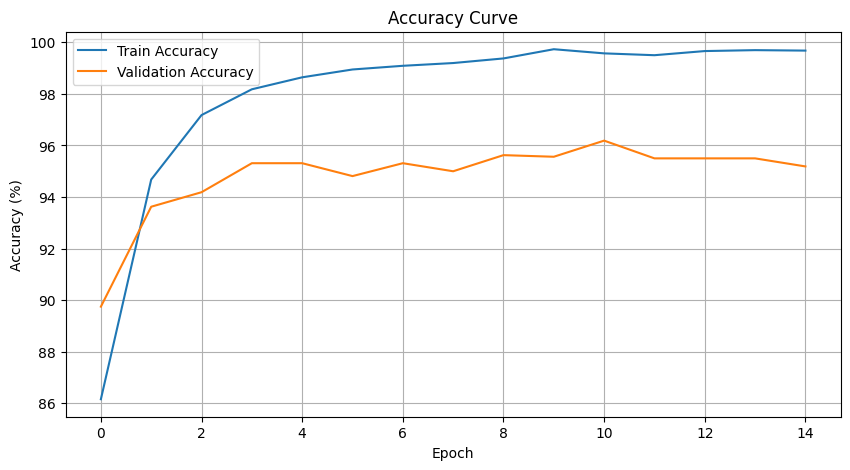

In [32]:
plt.figure(figsize=(10,5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.title("Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid()

plt.show()

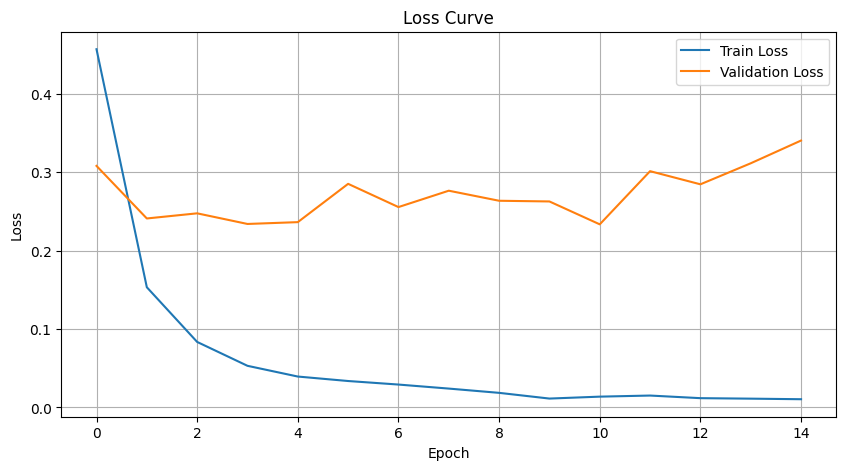

In [33]:
plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.title("Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

In [34]:
# ==========================================
# Collect Predictions
# ==========================================

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = best_model(images)

        _, predicted = torch.max(outputs,1)

        y_true.extend(labels.numpy())

        y_pred.extend(
            predicted.cpu().numpy()
        )

print("Prediction Collection Complete")

Prediction Collection Complete


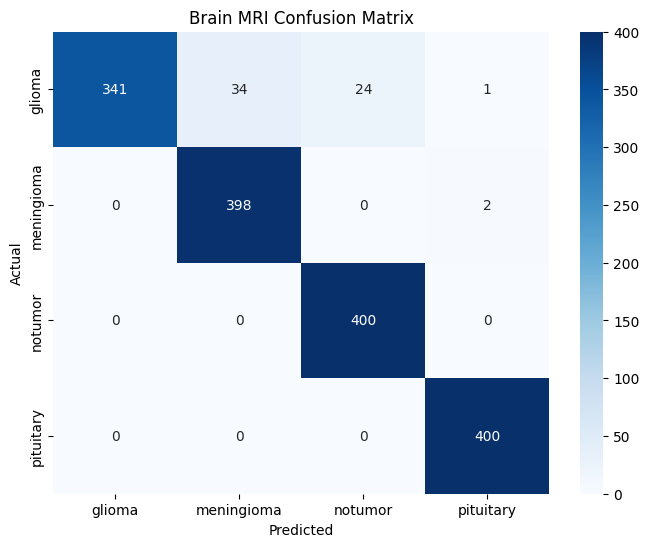

In [35]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Brain MRI Confusion Matrix")

plt.show()

In [36]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

      glioma       1.00      0.85      0.92       400
  meningioma       0.92      0.99      0.96       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



In [37]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'image_size': IMAGE_SIZE
}, 'brain_model_complete.pth')

print("Complete model file saved")

Complete model file saved


In [38]:
import os

print(os.path.exists("brain_model_complete.pth"))

True


In [39]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 67.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [41]:
# ==========================================
# Rebuild EfficientNet Architecture
# ==========================================

from torchvision import models
import torch.nn as nn

gradcam_model = models.efficientnet_b0(weights=None)

gradcam_model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(1280, 4)
)

checkpoint = torch.load(
    "brain_model_complete.pth",
    map_location=device
)

gradcam_model.load_state_dict(
    checkpoint["model_state_dict"]
)

gradcam_model.to(device)
gradcam_model.eval()

print("GradCAM Model Loaded")

GradCAM Model Loaded


In [42]:
# ==========================================
# Final Convolution Layer
# ==========================================

target_layers = [gradcam_model.features[-1]]

print(target_layers)

[Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)]


In [49]:
from google.colab import files

uploaded = files.upload()

Saving Te-gl_0012.jpg to Te-gl_0012.jpg


In [50]:
# ==========================================
# Get Uploaded Filename
# ==========================================

image_path = list(uploaded.keys())[0]

print(image_path)

Te-gl_0012.jpg


In [51]:
# ==========================================
# Image Preprocessing
# ==========================================

image = Image.open(image_path).convert("RGB")

display_image = image.copy()

image = image.resize((224,224))

image_np = np.array(image)

rgb_img = image_np.astype(np.float32) / 255.0

input_tensor = test_transforms(image).unsqueeze(0)

input_tensor = input_tensor.to(device)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [52]:
# ==========================================
# Prediction
# ==========================================

with torch.no_grad():

    outputs = gradcam_model(input_tensor)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    confidence, predicted_class = torch.max(
        probabilities,
        dim=1
    )

pred_idx = predicted_class.item()

pred_label = class_names[pred_idx]

conf = confidence.item() * 100

print("Prediction :", pred_label)
print("Confidence :", round(conf,2), "%")

Prediction : glioma
Confidence : 99.97 %


In [53]:
# ==========================================
# GradCAM
# ==========================================

cam = GradCAM(
    model=gradcam_model,
    target_layers=target_layers
)

targets = [
    ClassifierOutputTarget(pred_idx)
]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

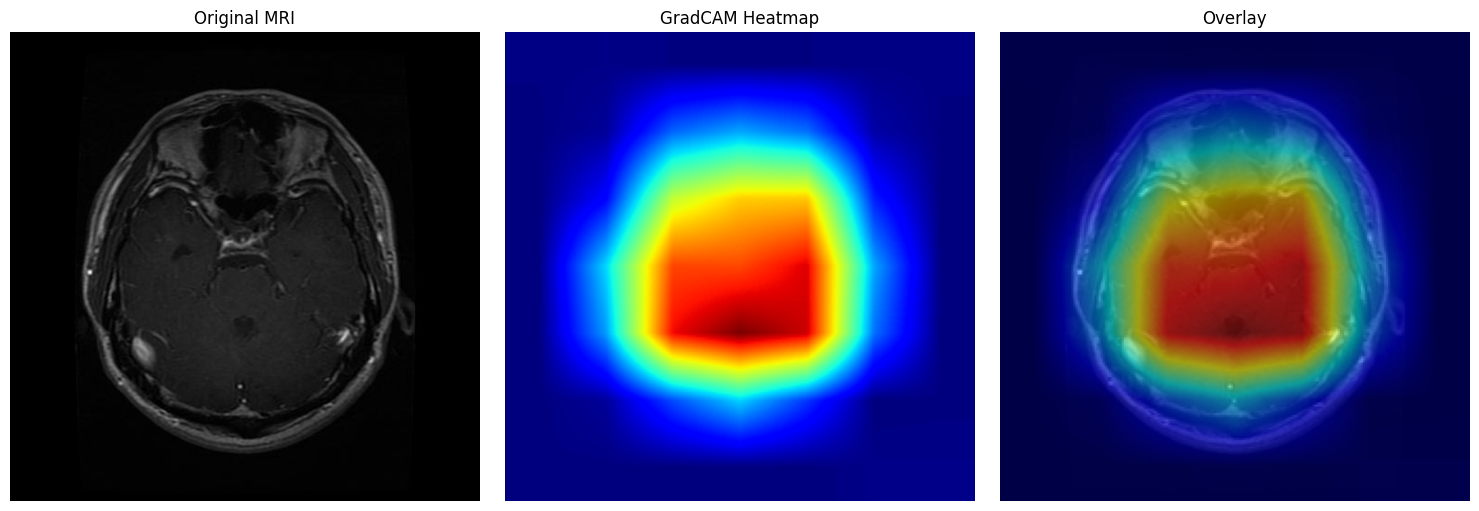

In [54]:
# ==========================================
# Overlay Heatmap
# ==========================================

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(display_image)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(grayscale_cam, cmap="jet")
plt.title("GradCAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(visualization)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [55]:
# ==========================================
# Load Metadata
# ==========================================

checkpoint = torch.load(
    "brain_model_complete.pth",
    map_location=device
)

class_names = checkpoint["class_names"]

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [56]:
# ==========================================
# Prediction Function
# ==========================================

def predict_mri(image_path):

    image = Image.open(image_path).convert("RGB")

    image = image.resize((224,224))

    input_tensor = test_transforms(image)

    input_tensor = input_tensor.unsqueeze(0)

    input_tensor = input_tensor.to(device)

    with torch.no_grad():

        outputs = gradcam_model(input_tensor)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[0]

    pred_idx = torch.argmax(
        probabilities
    ).item()

    pred_class = class_names[pred_idx]

    confidence = (
        probabilities[pred_idx].item() * 100
    )

    all_probs = {}

    for idx, class_name in enumerate(class_names):

        all_probs[class_name] = round(
            probabilities[idx].item() * 100,
            2
        )

    return (
        pred_class,
        confidence,
        all_probs
    )

In [58]:
image_path = "/content/33.jpg"

prediction, confidence, probs = predict_mri(image_path)

print("Prediction:", prediction)

print("Confidence:", round(confidence,2), "%")

print("\nClass Probabilities:\n")

for k, v in probs.items():

    print(f"{k}: {v}%")

Prediction: notumor
Confidence: 92.72 %

Class Probabilities:

glioma: 0.3%
meningioma: 6.73%
notumor: 92.72%
pituitary: 0.25%


In [59]:
# ==========================================
# Probability Display Function
# ==========================================

def show_probabilities(probs):

    plt.figure(figsize=(8,4))

    plt.bar(
        probs.keys(),
        probs.values()
    )

    plt.ylabel("Confidence (%)")

    plt.title("Brain MRI Classification Scores")

    plt.show()

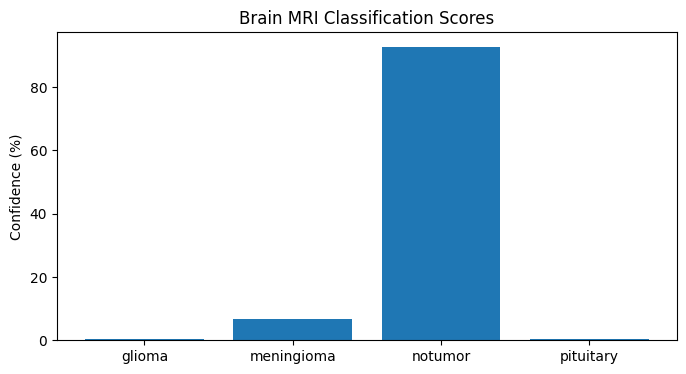

In [60]:
show_probabilities(probs)

In [61]:
# ==================================================
# Smart Clinical Report Generator
# ==================================================

def generate_report(prediction, confidence):

    confidence = round(confidence, 2)

    if prediction == "glioma":

        findings = (
            "MRI brain demonstrates imaging features "
            "suggestive of glioma."
        )

        impression = (
            f"Glioma detected with "
            f"{confidence}% confidence."
        )

        recommendation = (
            "Recommend neurology/neurosurgery consultation. "
            "Clinical correlation and further review advised."
        )

    elif prediction == "meningioma":

        findings = (
            "MRI brain demonstrates imaging features "
            "suggestive of meningioma."
        )

        impression = (
            f"Meningioma detected with "
            f"{confidence}% confidence."
        )

        recommendation = (
            "Recommend specialist evaluation and "
            "radiological correlation."
        )

    elif prediction == "pituitary":

        findings = (
            "MRI brain demonstrates imaging features "
            "suggestive of pituitary tumor."
        )

        impression = (
            f"Pituitary tumor detected with "
            f"{confidence}% confidence."
        )

        recommendation = (
            "Endocrinology and neurosurgical consultation "
            "may be considered."
        )

    else:

        findings = (
            "No significant imaging evidence of "
            "intracranial tumor identified."
        )

        impression = (
            f"No tumor detected with "
            f"{confidence}% confidence."
        )

        recommendation = (
            "Routine follow-up and clinical correlation "
            "recommended if symptoms persist."
        )

    report = f"""
==================================================
MEDVISION AI - BRAIN MRI ANALYSIS REPORT
==================================================

Findings:
{findings}

Impression:
{impression}

Recommendation:
{recommendation}

--------------------------------------------------
AI Generated Research Prototype Report
Not Intended For Clinical Diagnosis
--------------------------------------------------
"""

    return report

In [62]:
report = generate_report(
    prediction,
    confidence
)

print(report)


MEDVISION AI - BRAIN MRI ANALYSIS REPORT

Findings:
No significant imaging evidence of intracranial tumor identified.

Impression:
No tumor detected with 92.72% confidence.

Recommendation:
Routine follow-up and clinical correlation recommended if symptoms persist.

--------------------------------------------------
AI Generated Research Prototype Report
Not Intended For Clinical Diagnosis
--------------------------------------------------



In [63]:
# ==================================================
# Complete Brain MRI Analysis
# ==================================================

def analyze_mri(image_path):

    prediction, confidence, probs = predict_mri(
        image_path
    )

    report = generate_report(
        prediction,
        confidence
    )

    return {
        "prediction": prediction,
        "confidence": confidence,
        "probabilities": probs,
        "report": report
    }

In [64]:
result = analyze_mri(image_path)

print("Prediction:")
print(result["prediction"])

print("\nConfidence:")
print(round(result["confidence"],2))

print("\nReport:")
print(result["report"])

Prediction:
notumor

Confidence:
92.72

Report:

MEDVISION AI - BRAIN MRI ANALYSIS REPORT

Findings:
No significant imaging evidence of intracranial tumor identified.

Impression:
No tumor detected with 92.72% confidence.

Recommendation:
Routine follow-up and clinical correlation recommended if symptoms persist.

--------------------------------------------------
AI Generated Research Prototype Report
Not Intended For Clinical Diagnosis
--------------------------------------------------



In [65]:
def confidence_level(conf):

    if conf >= 95:
        return "Very High"

    elif conf >= 85:
        return "High"

    elif conf >= 70:
        return "Moderate"

    else:
        return "Low"

In [66]:
print(
    confidence_level(confidence)
)

High


In [67]:
!pip install reportlab -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.0 MB/s eta 0:00:00


In [68]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    PageBreak
)

from reportlab.lib.styles import (
    getSampleStyleSheet
)

from reportlab.lib import colors

from datetime import datetime

In [69]:
# ==================================================
# MedVision AI PDF Report Generator
# ==================================================

def create_pdf_report(
    prediction,
    confidence,
    report_text,
    filename="Brain_MRI_Report.pdf"
):

    doc = SimpleDocTemplate(filename)

    styles = getSampleStyleSheet()

    elements = []

    # ==========================================
    # Title
    # ==========================================

    title = Paragraph(
        "<b>MEDVISION AI</b>",
        styles["Title"]
    )

    elements.append(title)

    elements.append(
        Spacer(1,12)
    )

    subtitle = Paragraph(
        "<b>Brain MRI Analysis Report</b>",
        styles["Heading2"]
    )

    elements.append(subtitle)

    elements.append(
        Spacer(1,20)
    )

    # ==========================================
    # Timestamp
    # ==========================================

    timestamp = datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    elements.append(
        Paragraph(
            f"<b>Generated:</b> {timestamp}",
            styles["Normal"]
        )
    )

    elements.append(
        Spacer(1,10)
    )

    # ==========================================
    # Prediction
    # ==========================================

    elements.append(
        Paragraph(
            f"<b>Prediction:</b> {prediction}",
            styles["Normal"]
        )
    )

    elements.append(
        Paragraph(
            f"<b>Confidence:</b> {confidence:.2f}%",
            styles["Normal"]
        )
    )

    elements.append(
        Spacer(1,20)
    )

    # ==========================================
    # Report
    # ==========================================

    elements.append(
        Paragraph(
            "<b>Clinical Analysis</b>",
            styles["Heading2"]
        )
    )

    elements.append(
        Spacer(1,10)
    )

    report_text = report_text.replace(
        "\n",
        "<br/>"
    )

    elements.append(
        Paragraph(
            report_text,
            styles["BodyText"]
        )
    )

    elements.append(
        Spacer(1,20)
    )

    # ==========================================
    # Footer
    # ==========================================

    disclaimer = """
    <b>Disclaimer:</b><br/>
    This report was generated by a research prototype.
    It is intended for educational, research, and
    demonstration purposes only and must not be used
    as a substitute for professional medical diagnosis.
    """

    elements.append(
        Paragraph(
            disclaimer,
            styles["Italic"]
        )
    )

    doc.build(elements)

    return filename

In [70]:
pdf_path = create_pdf_report(
    prediction=result["prediction"],
    confidence=result["confidence"],
    report_text=result["report"]
)

print("PDF Generated:", pdf_path)

PDF Generated: Brain_MRI_Report.pdf


In [71]:
import os

print(
    os.path.exists(
        "Brain_MRI_Report.pdf"
    )
)

True


In [72]:
from google.colab import files

files.download(
    "Brain_MRI_Report.pdf"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
!pip install gradio grad-cam reportlab -q

In [74]:
import os

os.makedirs("MedVision_Brain", exist_ok=True)

print("Project Folder Created")

Project Folder Created


In [75]:
requirements = """
torch
torchvision
numpy
opencv-python
Pillow
matplotlib
gradio
grad-cam
reportlab
"""

with open("requirements.txt","w") as f:
    f.write(requirements)

print("requirements.txt created")

requirements.txt created


In [76]:
!pip install -q gradio